# Epoched Decoding Analysis — FL replay, encoding & retrieval reactivation (switchable)

One notebook, one `SOURCE` switch (config cell). `fl` replays the FL training
recording (in-sample; the honest metric is the CV-AUC cell). `encoding` and
`retrieval` are leakage-free held-out tests over the real-time task's
couple-learning and retrieval phases — both replay the task recording fresh
through the same `OnlinePreprocessor` + `engine` as FL (not a fixed past live
session's `predictions.csv`), so any model/hyperparameters/pos-neg classes you
try applies to every source, not just FL. `encoding` epochs around each image
onset (same-modality perception check); `retrieval` epochs around each
retrieval cue, labeled with the cued couple's true (encoded) category
recovered from the encoding markers earlier in the same recording
(`analysis_lib.task_labels`). Only the data-loading/epoching cells branch on
`SOURCE`; the rest (plots, confusion, summary table) is shared. The heavy
lifting lives in `analysis_lib` (`context`, `streaming`, `sources`, `metrics`,
`plots`, `task_labels`), so the cells stay thin. Two cells (stimulus-order
diagnostic, offline/online parity) are FL-only and self-skip.


In [81]:
%load_ext autoreload
%autoreload 2
from analysis_lib import context
REPO_ROOT = context.bootstrap()                     # repo-root walk + sys.path
from analysis_lib import streaming, sources, plots, task_labels, metrics
import numpy as np
import matplotlib; matplotlib.use("inline")
import matplotlib.pyplot as plt
import mne; mne.set_log_level("ERROR")
print("repo root:", REPO_ROOT)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
repo root: C:\Users\itaip\projects\live-reactivation-decoder


## Knobs

In [82]:
# ── Knobs ───────────────────────────────────────────────────────────────────────
ROOT = "debug_snapshots/animacy_fl_c1"   # analysis root: a seeded debug snapshot
                                       # (SessionPaths layout + manifest.yaml referencing
                                       # its FL recording and, optionally, a task recording)

# RECORDING SOURCE:
#   "fl"         replay the FL TRAINING recording (in-sample -> P(t) is a
#                sanity/behaviour view, NOT a performance number; see CV-AUC).
#   "encoding"   held-out ENCODING (couple-learning) phase of the real-time task —
#                fresh replay of the task recording, epoched around each image
#                onset. Same-modality (perception) sanity check: an image really
#                was shown, unlike retrieval.
#   "retrieval"  held-out RETRIEVAL phase of the real-time task — fresh replay of
#                the task recording, epoched around each retrieval cue and labeled
#                with the cued couple's true (encoded) category. The real
#                reactivation-from-memory question.
SOURCE = "fl"  # "fl" | "encoding" | "retrieval"

MAX_SECONDS = None          # None = whole recording; a number crops (quick dev iteration).
BATCH_SIZE_SAMPLES = 40     # mirror StreamWorker's micro-batch.
# encoding/retrieval reuse the FL epoch window (ctx.epoch_tmin/epoch_tmax) by
# default, set in the "Build context" cell below.

# Winner-take-all rule for the confusion cell:
#   "weighted_prob" = argmax of each decoder's Gaussian tp-weighted mean P(t)
#                     (WINNER_SIGMA s around its trained tp); "vote" = per-timepoint
#                     argmax majority. Flip to compare metrics.
WINNER_MODE  = "weighted_prob"  # "weighted_prob" | "vote"
WINNER_SIGMA = 0.01
MARKERS_OF_INTEREST = None  # FL: subset of markers; None = every decoder's positive label.


## Build context (profile → settings / artifact / preproc / engine)

In [83]:
IS_FL = SOURCE == "fl"
ctx = context.load_context(ROOT)
engine = ctx.engine()
eci = list(ctx.artifact.online_state["eeg_chunk_indices"])

# FL: each raw marker is its own display group. encoding/retrieval: pool the
# per-image markers into the two encoded categories (learning_<category>_NN
# shares the category prefix with the FL image names) so decoder positive-label
# sets and trial labels line up on the same group names.
marker_groups = None if IS_FL else task_labels.marker_groups_by_category(ctx.event_mapping)
dc = plots.display_config(ctx, marker_groups=marker_groups, markers_of_interest=MARKERS_OF_INTEREST)

RECORDING_DIR = ctx.raw_dirs.get("functinal_localizer") if IS_FL else ctx.raw_dirs.get("task")
assert RECORDING_DIR is not None, f"no raw dir for source={SOURCE!r} in {sorted(ctx.raw_dirs)}"
EPOCH_TMIN, EPOCH_TMAX = ctx.epoch_tmin, ctx.epoch_tmax   # shared by all three sources

assert engine.feature_width == ctx.preproc.n_channels
print("SOURCE   :", SOURCE)
print("root     :", ctx.paths.root)
print("recording:", RECORDING_DIR)
print("decoders :", list(ctx.artifact.models), "| display:", dc.display_markers)


SOURCE   : fl
root     : C:\Users\itaip\projects\live-reactivation-decoder\debug_snapshots\animacy_fl_c1
recording: C:\Users\itaip\projects\live-reactivation-decoder\data\sub_001\functinal_localizer
decoders : ['animate decoder', 'inanimate decoder'] | display: ['animate_01', 'animate_02', 'animate_03', 'inanimate_01', 'inanimate_02', 'inanimate_03']


## Cross-validated AUC per decoder — the honest metric

running 2-decoder temporal-generalization CV (604 epochs, 121 timepoints)...
  [1/2] animate decoder done
  [2/2] inanimate decoder done


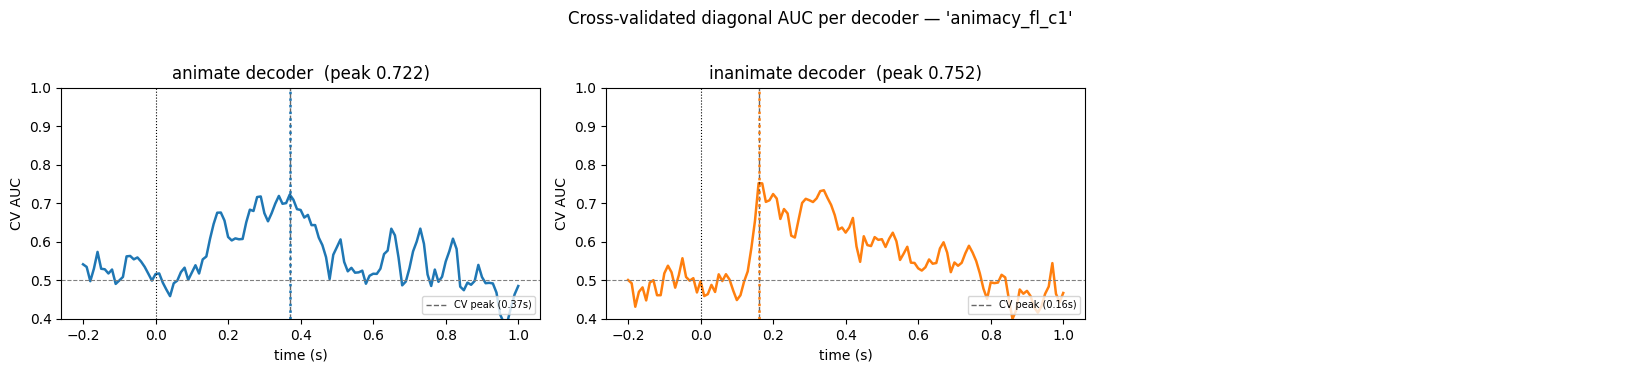

average peak AUC: 0.726 | suggested timepoint: 0.340s


In [84]:
eval_results = plots.cv_auc(ctx)

## Try an alternate decoding timepoint (opt-in, in-memory only — never saved)

Off by default (`TRY_CUSTOM_TIMEPOINTS = False`) — flip it on and edit
`CUSTOM_TIMEPOINTS` to retrain whichever decoder(s) you want at a different
timepoint (e.g. one you liked on the CV-AUC plot above). Reuses
`backend.offline_phase.trainer.ModelTrainer` — the same fit the app's Phase 1
Confirm+Train step performs — but purely in memory: `decoder_pipeline.joblib`
on disk is never touched. `engine` (used by every `SOURCE` below) is swapped
to the retrained model(s), and the CV-AUC plot is redrawn — cheaply, reusing
`eval_results` rather than re-running the ~3+ minute cross-validation — with
the newly chosen timepoint marked alongside the CV peak and the original
trained tp.


using custom timepoints: {'animate decoder': 0.18, 'inanimate decoder': 0.16}


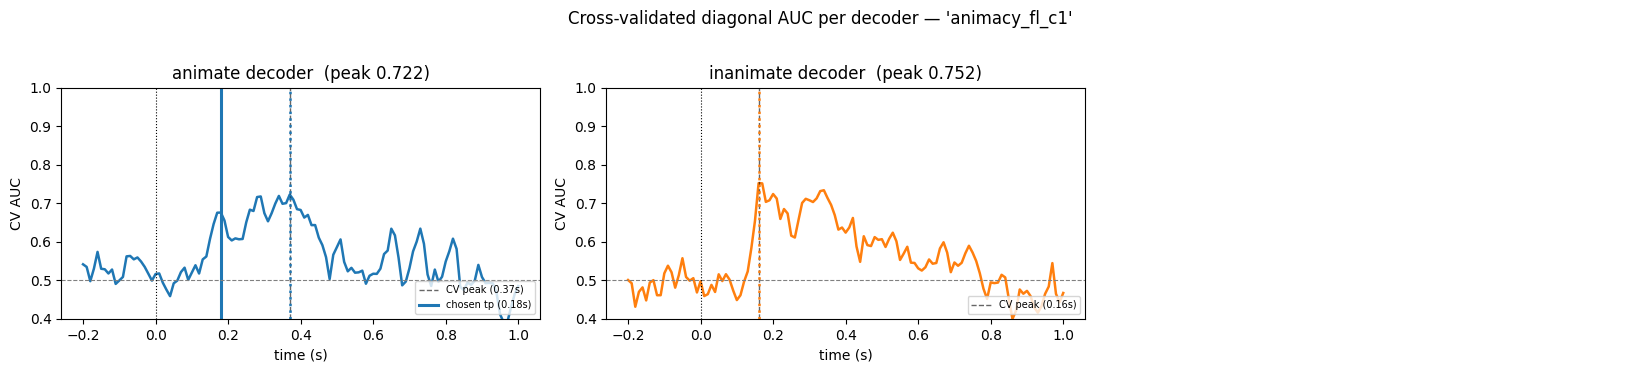

average peak AUC: 0.726 | suggested timepoint: 0.340s


In [85]:
TRY_CUSTOM_TIMEPOINTS = True
CUSTOM_TIMEPOINTS = {name: ctx.task_tp(name) for name in ctx.artifact.models}
CUSTOM_TIMEPOINTS["animate decoder"] = 0.18   # edit whichever decoder(s) you want to change

if TRY_CUSTOM_TIMEPOINTS:
    import glob

    import mne

    from backend.offline_phase.trainer import ModelTrainer

    epo_fif = sorted(glob.glob(str(ctx.paths.epochs_dir / "*epo.fif")))
    epochs = mne.read_epochs(epo_fif[0], verbose=False)
    # ModelTrainer always retrains every decoder in the config (it has no
    # partial-retrain mode) — so this refits all of them, even ones left at
    # their current timepoint above; a few seconds each, not worth avoiding.
    models = ModelTrainer(epochs, ctx.settings.get_decoder_settings()).run_training(CUSTOM_TIMEPOINTS)["models"]
    engine = ctx.engine(models)
    print("using custom timepoints:", CUSTOM_TIMEPOINTS)
    # Plot BEFORE updating ctx.task_tp bookkeeping, so "trained tp" (dotted)
    # still shows where the shipped model was actually trained, distinct from
    # "chosen tp" (solid) on this one comparison plot.
    plots.plot_cv_auc(ctx, eval_results, custom_tp=CUSTOM_TIMEPOINTS)
    # Then propagate the choice so every later cell (per_decoder, selectivity,
    # competition, confusion_and_perm, timepoint_table, save_run_summary) marks
    # / uses the new timepoint instead of the shipped one — they all describe
    # "the currently active decoder", which has now changed.
    ctx._tp_by_task.update(CUSTOM_TIMEPOINTS)
else:
    print("using the snapshot's shipped timepoints:", CUSTOM_TIMEPOINTS)


## Load the recording

In [86]:
raw, eeg, sfreq = streaming.load_recording(RECORDING_DIR, MAX_SECONDS)
n_times, n_fed = eeg.shape
assert max(eci) < n_fed, "channel/EMG alignment mismatch (eeg_chunk_indices vs fed channels)"
print(f"sfreq={sfreq:g} Hz | fed EEG channels={n_fed} | samples={n_times} ({n_times/sfreq:.1f}s)")


sfreq=1000 Hz | fed EEG channels=64 | samples=2747055 (2747.1s)


## Markers → labeled samples (FL only — encoding/retrieval build their epochs directly, see below)


In [87]:
if IS_FL:
    samples_by_group, info = sources.build_fl_samples(ctx, raw, dc, n_times=n_times)
    print(info)
    print("samples per group:", {k: len(v) for k, v in sorted(samples_by_group.items())})


FL markers: {'inanimate_02': 50, 'animate_01': 50, 'animate_02': 50, 'inanimate_01': 50, 'inanimate_03': 50, 'animate_03': 50}
samples per group: {'animate_01': 50, 'animate_02': 50, 'animate_03': 50, 'inanimate_01': 50, 'inanimate_02': 50, 'inanimate_03': 50}


## Replay through the online inference path

In [88]:
features, out_samples, fs_out = streaming.run_online_stream(
    ctx.preproc, eeg, batch_size=BATCH_SIZE_SAMPLES)
preds = engine.predict(features)
print(f"output rows={features.shape[0]} @ {fs_out:g} Hz | tasks={list(preds)}")


output rows=274706 @ 100 Hz | tasks=['animate decoder', 'inanimate decoder']


## Epoch the probability stream (FL) / label & epoch encoding+retrieval trials (both from the same fresh replay)


In [89]:
if IS_FL:
    t_grid, epoch_stream = streaming.make_epocher(out_samples, sfreq, fs_out, EPOCH_TMIN, EPOCH_TMAX)

    # Keep only display groups that actually occur in this recording (drives every view).
    dc.display_markers = [m for m in dc.display_markers if m in samples_by_group]
    epoched = {t: {g: epoch_stream(prob, sorted(samples_by_group.get(g, [])))
                   for g in dc.display_markers}
               for t, prob in preds.items()}
else:
    build_epochs = {"encoding": sources.build_encoding_epochs,
                    "retrieval": sources.build_retrieval_epochs}[SOURCE]
    t_grid, epoched, trials, info = build_epochs(
        ctx, raw, dc, out_samples, sfreq, fs_out, preds, tmin=EPOCH_TMIN, tmax=EPOCH_TMAX, n_times=n_times)
    print(info)

print("epochs per group:", {g: epoched[next(iter(preds))][g].shape[0] for g in dc.display_markers})


epochs per group: {'animate_01': 50, 'animate_02': 50, 'animate_03': 50, 'inanimate_01': 50, 'inanimate_02': 50, 'inanimate_03': 50}


## Stimulus-order diagnostic

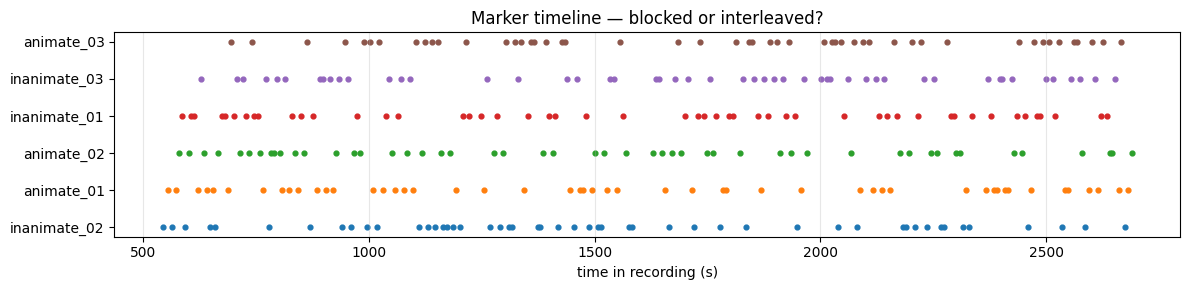

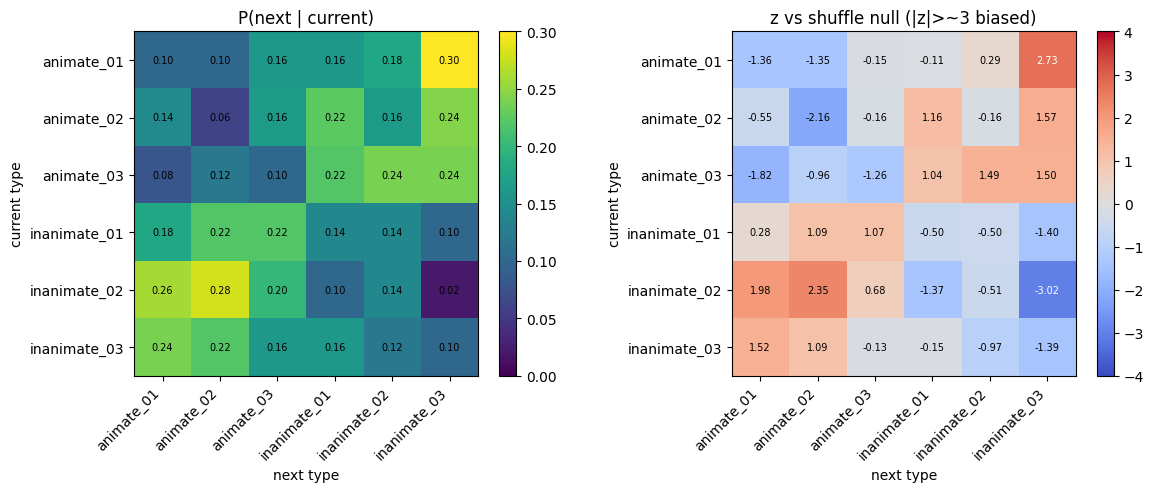

global transition test: shuffle p=0.006 ⚠ ordering bias


In [90]:
if IS_FL:
    plots.fl_marker_diagnostic(ctx, raw, dc)
else:
    times = [t["t"] / sfreq for t in trials]
    labels = [t["true_label"] for t in trials]
    plots.marker_order_diagnostic(times, labels, title_prefix=SOURCE.capitalize())


## Per-decoder response to its own positive group

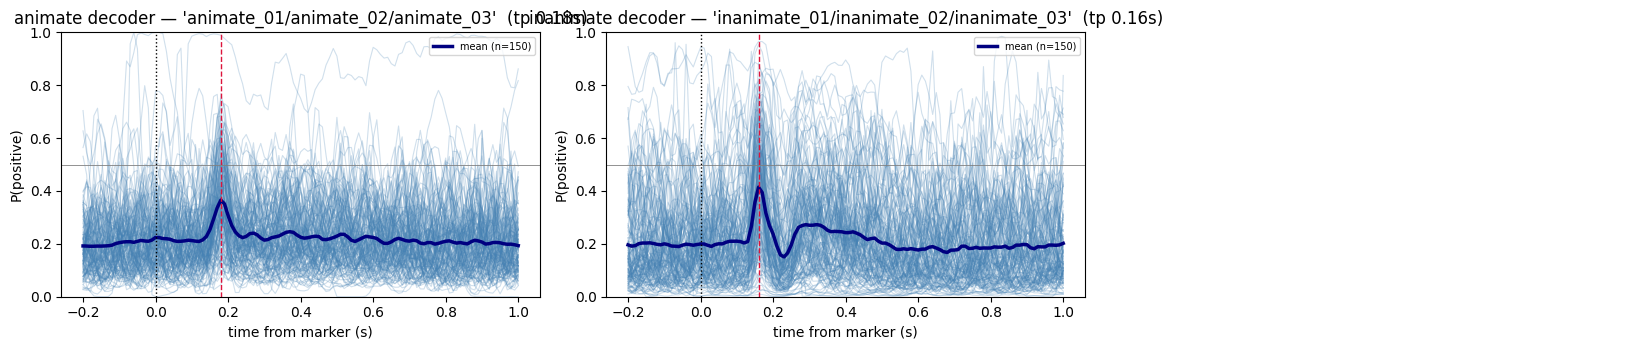

In [91]:
plots.per_decoder(ctx, dc, epoched, t_grid, preds)

## Selectivity — every group overlaid per decoder

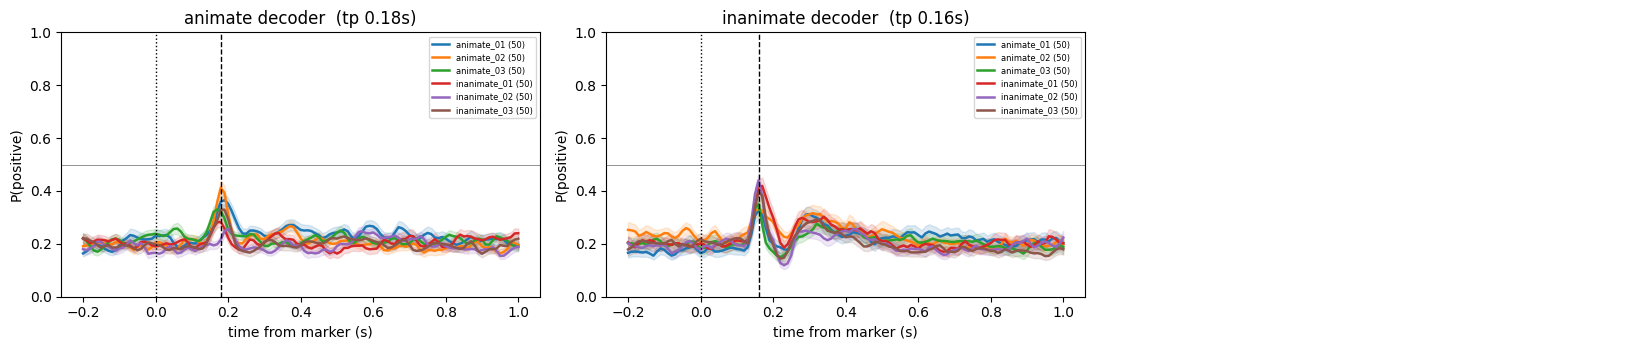

In [92]:
plots.selectivity(ctx, dc, epoched, t_grid, preds)

## Decoder competition per group — raw vs baseline-corrected

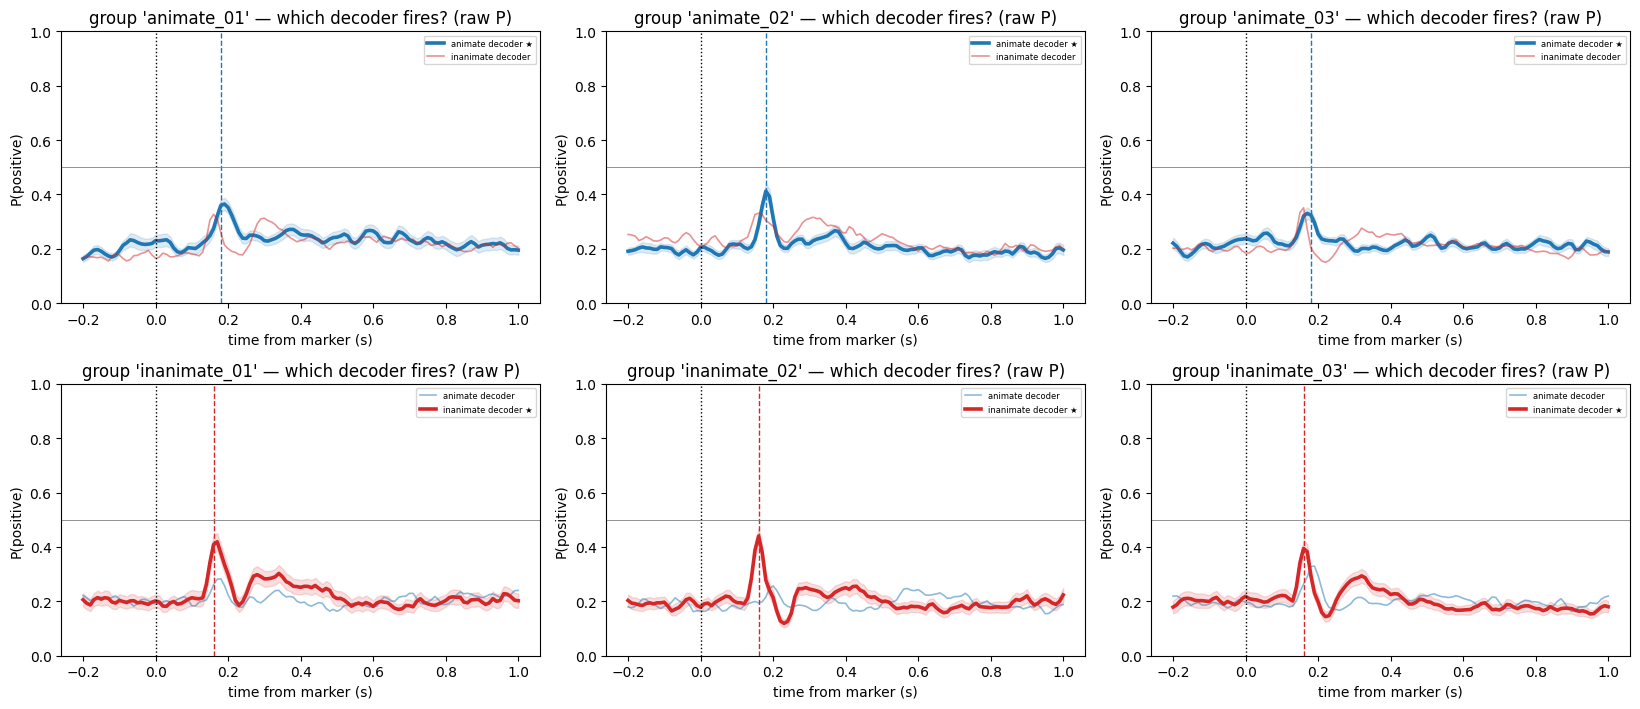

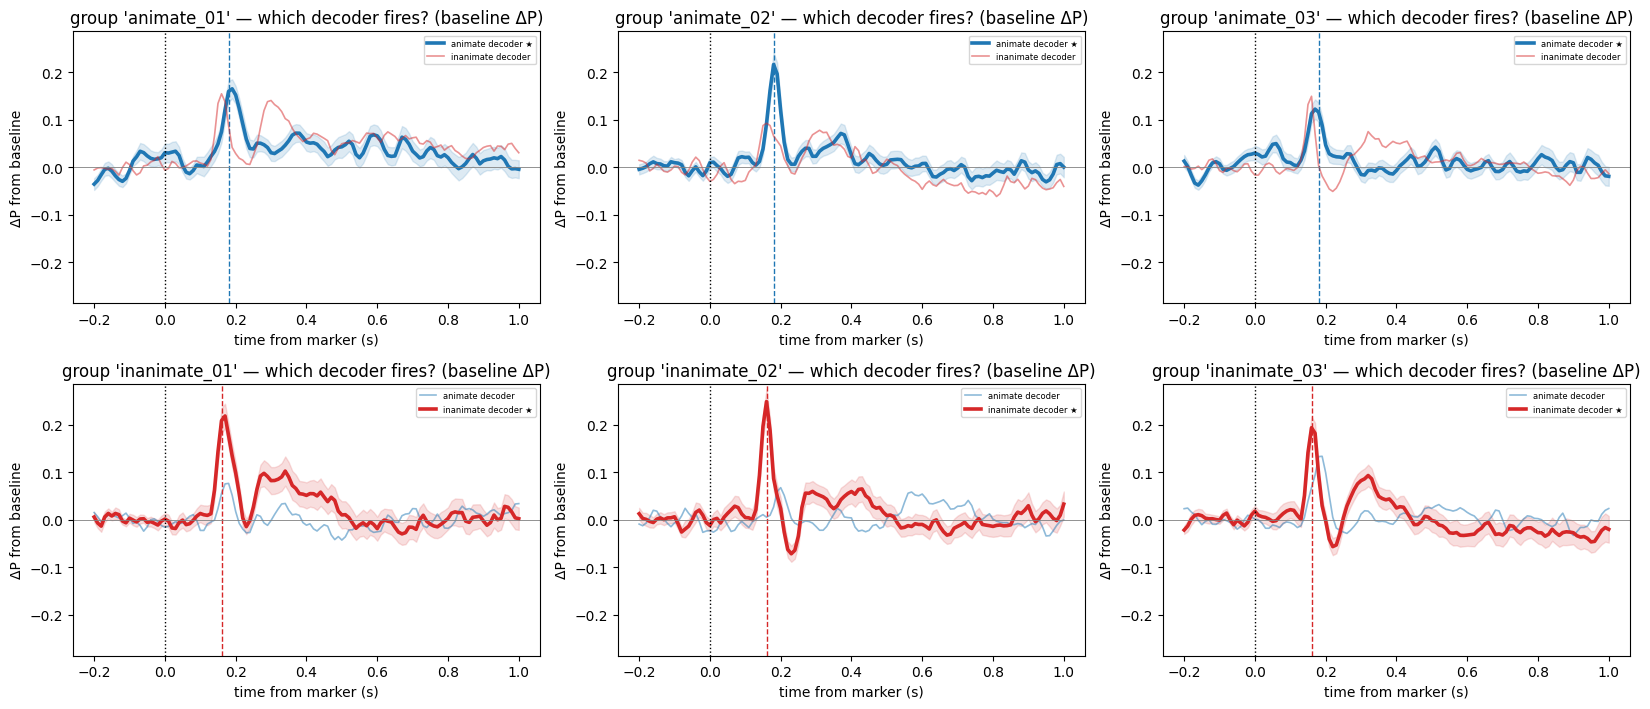

In [93]:
plots.competition(ctx, dc, epoched, t_grid, preds)

## Winner confusion + label permutation — raw vs baseline-corrected

[weighted_prob, raw] animate_01/inanimate_01: accuracy=0.620 (chance 0.50) | macro precision 0.620, recall 0.620


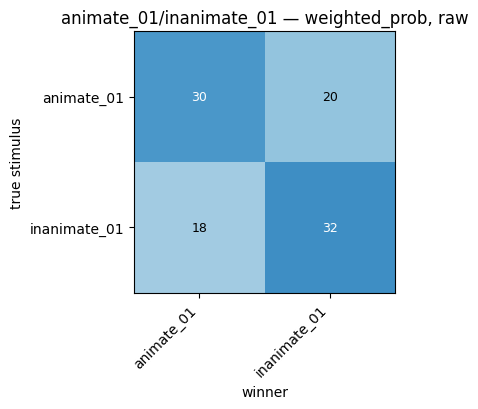

[weighted_prob, baseline ΔP] animate_01/inanimate_01: accuracy=0.580 (chance 0.50) | macro precision 0.585, recall 0.580


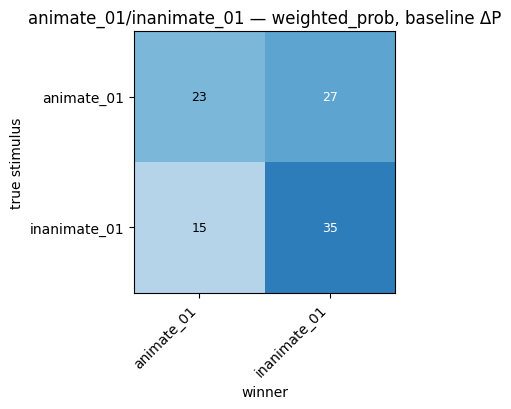

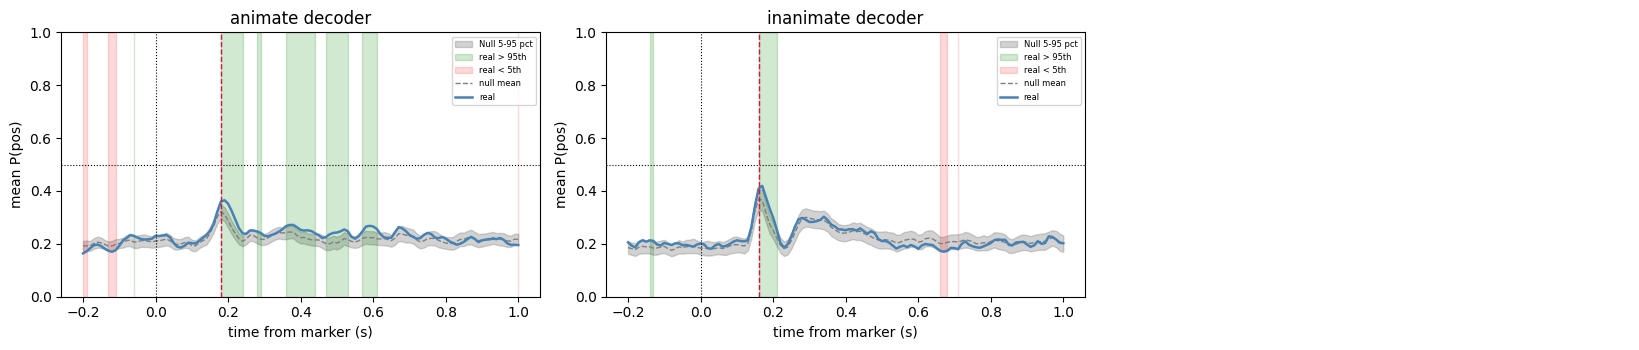

In [94]:
plots.confusion_and_perm(ctx, dc, epoched, t_grid, preds,
                         ctx.settings.get_decoder_settings()["tasks"],
                         mode=WINNER_MODE, sigma=WINNER_SIGMA)

## Offline vs online parity *(FL only)*

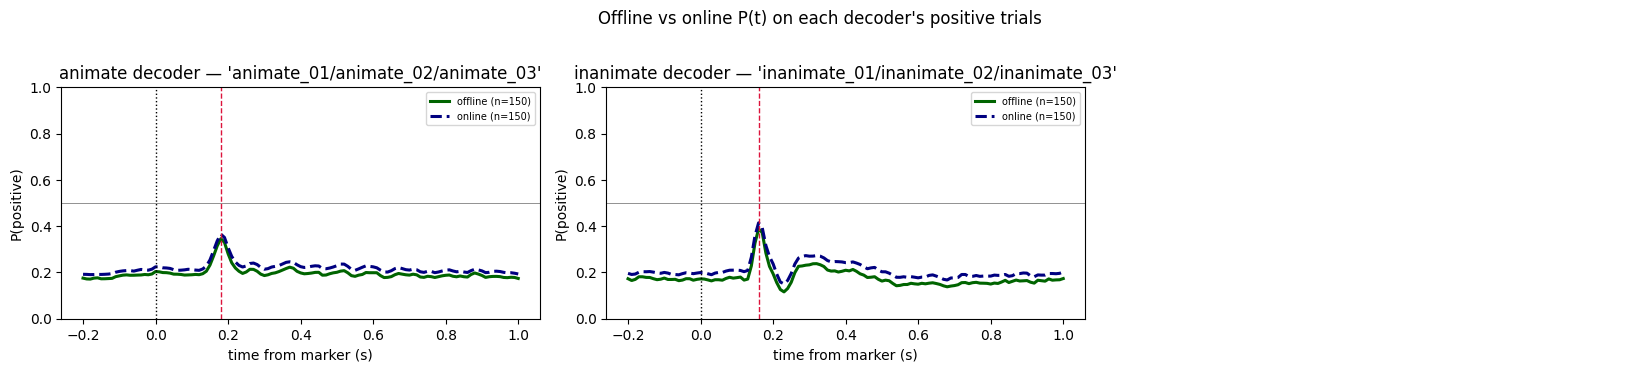

In [95]:
if IS_FL:
    plots.parity(ctx, dc, epoched, t_grid, preds, models=engine.models)
else:
    print("offline/online parity is FL-only — skipped for task sources")


## Summary table — each decoder at its own trained timepoint

In [96]:
plots.timepoint_table(ctx, dc, epoched, t_grid, preds)

task                     tp(s)   animate_01   animate_02   animate_03 inanimate_01 inanimate_02 inanimate_03
------------------------------------------------------------------------------------------------------------
animate decoder           0.18        0.359        0.412        0.324        0.283        0.216        0.329
inanimate decoder         0.16        0.327        0.331        0.351        0.409        0.440        0.395


## Save run summary

In [97]:
out = context.save_run_summary(ctx, dc, epoched, t_grid, preds, eval_results,
                              source=SOURCE, max_seconds=MAX_SECONDS)
print("saved", out)

saved C:\Users\itaip\projects\live-reactivation-decoder\debug_snapshots\animacy_fl_c1\live_summary.joblib
